## Dataset Folder Structure

In [1]:
import sys
print(sys.executable)

c:\ML_Workspace\venv\Scripts\python.exe


In [2]:
import os

dataset_path = r"D:\00 Study\Projects\DM\dataset"

for root, dirs, files in os.walk(dataset_path):

    level = root.replace(dataset_path, "").count(os.sep)

    indent = " " * 4 * level

    print(f"{indent}{os.path.basename(root)}/")

    subindent = " " * 4 * (level + 1)

    for f in files[:5]:  # show first 5 files only
        print(f"{subindent}{f}")

    if len(files) > 5:
        print(f"{subindent}... ({len(files)} files)")

dataset/
    test/
        images/
            img_sylhet_000001.tif
            img_sylhet_000002.tif
            img_sylhet_000003.tif
            img_sylhet_000004.tif
            img_sylhet_000005.tif
            ... (3125 files)
        labels/
            label_sylhet_000001.tif
            label_sylhet_000002.tif
            label_sylhet_000003.tif
            label_sylhet_000004.tif
            label_sylhet_000005.tif
            ... (3125 files)
    train/
        images/
            img_dhaka_000001.tif
            img_dhaka_000002.tif
            img_dhaka_000003.tif
            img_dhaka_000004.tif
            img_dhaka_000005.tif
            ... (7969 files)
        labels/
            label_dhaka_000001.tif
            label_dhaka_000002.tif
            label_dhaka_000003.tif
            label_dhaka_000004.tif
            label_dhaka_000005.tif
            ... (7969 files)
    valid/
        images/
            img_dhaka_000016.tif
            img_dhaka_000041.tif
       

## Dataset Analization

In [3]:
from pathlib import Path

BASE = Path(r"D:\00 Study\Projects\DM\dataset")

TRAIN_IMG  = BASE / "train"  / "images"
TRAIN_LBL  = BASE / "train"  / "labels"
VALID_IMG  = BASE / "valid"  / "images"
VALID_LBL  = BASE / "valid"  / "labels"
TEST_IMG   = BASE / "test"   / "images"
TEST_LBL   = BASE / "test"   / "labels"

print("Train images :", len(list(TRAIN_IMG.glob("*.tif"))))
print("Train labels :", len(list(TRAIN_LBL.glob("*.tif"))))
print("Valid images :", len(list(VALID_IMG.glob("*.tif"))))
print("Valid labels :", len(list(VALID_LBL.glob("*.tif"))))
print("Test  images :", len(list(TEST_IMG.glob("*.tif"))))
print("Test  labels :", len(list(TEST_LBL.glob("*.tif"))))


Train images :

 7969
Train labels : 7969
Valid images : 1406
Valid labels : 1406
Test  images : 3125
Test  labels : 3125


In [4]:
import rasterio
import numpy as np

sample_img  = sorted(TRAIN_IMG.glob("*.tif"))[0]
sample_lbl  = sorted(TRAIN_LBL.glob("*.tif"))[0]

with rasterio.open(sample_img) as src:
    img = src.read().astype(np.float32)   # (4, 256, 256)

with rasterio.open(sample_lbl) as src:
    lbl = src.read(1).astype(np.int64)    # (256, 256)

print("Image shape :", img.shape)
print("Label shape :", lbl.shape)
print("Image min   :", img.min())
print("Image max   :", img.max())
print("Label classes:", np.unique(lbl))

Image shape : (4, 256, 256)
Label shape : (256, 256)
Image min   : 285.0
Image max   : 4388.0
Label classes: [0 1 2 3]


In [5]:
from tqdm.notebook import tqdm

class_counts = np.zeros(4, dtype=np.int64)

for lbl_path in tqdm(sorted(TRAIN_LBL.glob("*.tif"))):
    with rasterio.open(lbl_path) as src:
        lbl = src.read(1).astype(np.int64)
    for c in range(4):
        class_counts[c] += (lbl == c).sum()

total = class_counts.sum()
names = ["Water", "Trees", "Buildings", "Open Land"]

print("\nClass Distribution (train set)")
print("-" * 40)
for i, (name, cnt) in enumerate(zip(names, class_counts)):
    print(f"  {i} {name:<12}: {cnt:>12,}  ({100*cnt/total:.2f}%)")
print(f"  {'Total':<14}: {total:>12,}")

  0%|          | 0/7969 [00:00<?, ?it/s]


Class Distribution (train set)
----------------------------------------
  0 Water       :  149,695,903  (28.66%)
  1 Trees       :  143,371,348  (27.45%)
  2 Buildings   :   76,727,915  (14.69%)
  3 Open Land   :  152,461,218  (29.19%)
  Total         :  522,256,384


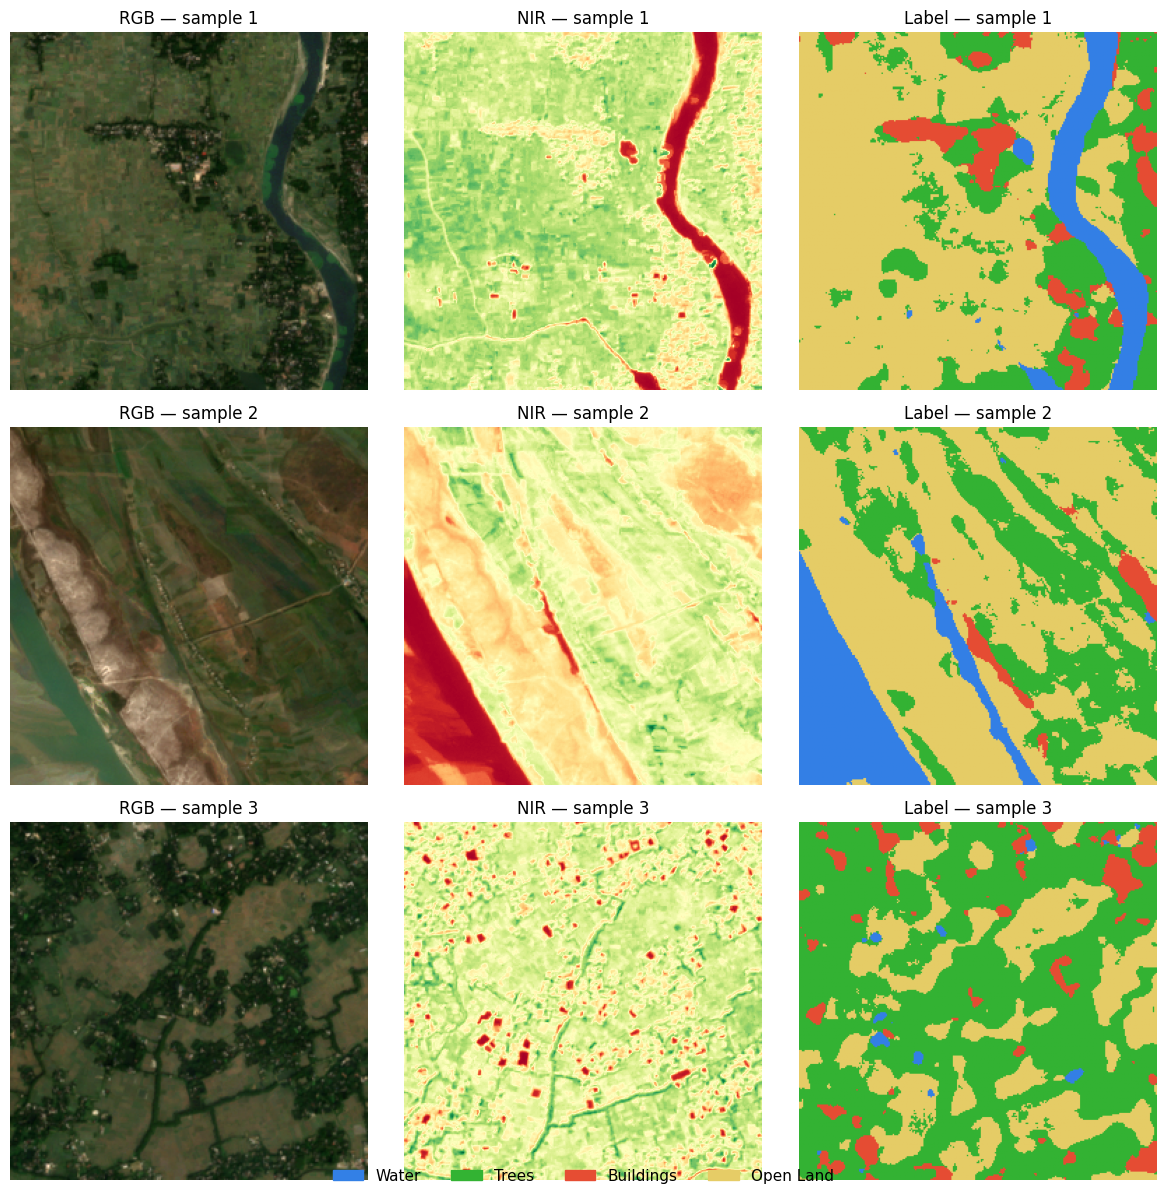

Saved: sample_verification.png


In [6]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

MEAN = np.array([637.189342, 871.552721, 772.949392, 1985.648665])
STD  = np.array([263.729817, 277.694238, 351.328225, 1025.712170])

CLASS_COLORS = {
    0: (0.2, 0.5, 0.9),   # Water   — blue
    1: (0.2, 0.7, 0.2),   # Trees   — green
    2: (0.9, 0.3, 0.2),   # Buildings — red
    3: (0.9, 0.8, 0.4),   # Open Land — yellow
}
CLASS_NAMES = {0:"Water", 1:"Trees", 2:"Buildings", 3:"Open Land"}

def label_to_rgb(lbl):
    h, w = lbl.shape
    rgb = np.zeros((h, w, 3))
    for cls, color in CLASS_COLORS.items():
        mask = lbl == cls
        rgb[mask] = color
    return rgb

img_files = sorted(TRAIN_IMG.glob("*.tif"))
lbl_files = sorted(TRAIN_LBL.glob("*.tif"))

fig, axes = plt.subplots(3, 3, figsize=(12, 12))

for row in range(3):
    with rasterio.open(img_files[row * 500]) as src:
        img = src.read().astype(np.float32)
    with rasterio.open(lbl_files[row * 500]) as src:
        lbl = src.read(1).astype(np.int64)

    # RGB display (bands B4, B3, B2 = Red, Green, Blue)
    rgb = np.stack([img[2], img[1], img[0]], axis=-1)
    rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min() + 1e-6)

    # NIR display (B8)
    nir = img[3]
    nir = (nir - nir.min()) / (nir.max() - nir.min() + 1e-6)

    axes[row][0].imshow(rgb)
    axes[row][0].set_title(f"RGB — sample {row+1}")
    axes[row][0].axis("off")

    axes[row][1].imshow(nir, cmap="RdYlGn")
    axes[row][1].set_title(f"NIR — sample {row+1}")
    axes[row][1].axis("off")

    axes[row][2].imshow(label_to_rgb(lbl))
    axes[row][2].set_title(f"Label — sample {row+1}")
    axes[row][2].axis("off")

patches = [mpatches.Patch(color=c, label=CLASS_NAMES[i])
           for i, c in CLASS_COLORS.items()]
fig.legend(handles=patches, loc="lower center",
           ncol=4, fontsize=11, frameon=False)
plt.tight_layout()
plt.savefig("sample_verification.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: sample_verification.png")

In [7]:
print("hello")

hello


## Main Training Pipeline

In [8]:
!pip install segmentation-models-pytorch -q
!pip install albumentations -q

### Cell 1 — Install and Imports

In [9]:

import os, json, random, time
import numpy as np
import pandas as pd
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import segmentation_models_pytorch as smp
import albumentations as A
from albumentations.pytorch import ToTensorV2

import rasterio
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from tqdm.notebook import tqdm

# ── reproducibility ──────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = True   # safe: fixed input size

# ── AMP scaler (mixed precision) ─────────────────────────
scaler = torch.cuda.amp.GradScaler()

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device :", DEVICE)
print("PyTorch:", torch.__version__)
print("SMP    :", smp.__version__)

Device : cuda
PyTorch: 2.11.0+cu128
SMP    : 0.5.0


C:\Users\works\AppData\Local\Temp\ipykernel_16752\256395900.py:29: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


### Cell 2 — Config (single source of truth)

In [17]:
# ═══════════════════════════════════════════════════════
#  ALL HYPERPARAMETERS IN ONE PLACE
# ═══════════════════════════════════════════════════════

# Your local dataset folder
BASE = Path(r"C:\DM\dataset")

TRAIN_IMG = BASE / "train"  / "images"
TRAIN_LBL = BASE / "train"  / "labels"
VALID_IMG = BASE / "valid"  / "images"
VALID_LBL = BASE / "valid"  / "labels"
TEST_IMG  = BASE / "test"   / "images"
TEST_LBL  = BASE / "test"   / "labels"

# A new folder for your saved models and graphs
OUTPUT_DIR = Path(r"D:\00 Study\Projects\DM\outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

# ── normalization (computed from your train set) ─────────
MEAN = np.array([637.189342, 871.552721, 772.949392, 1985.648665], dtype=np.float32)
STD  = np.array([263.729817, 277.694238, 351.328225, 1025.712170], dtype=np.float32)

# ── model ────────────────────────────────────────────────
NUM_CLASSES  = 4
IN_CHANNELS  = 4
ENCODER      = "efficientnet-b4"
ENCODER_WEIGHTS = "imagenet"   # pretrained, we adapt for 4 bands

# ── training ─────────────────────────────────────────────
BATCH_SIZE   = 16
NUM_WORKERS  = 0
MAX_EPOCHS   = 80
LR           = 1e-4
WEIGHT_DECAY = 1e-4
PATIENCE     = 12          # early stopping on val mIoU

# ── class names and colors ───────────────────────────────
CLASS_NAMES  = ["Water", "Trees", "Buildings", "Open Land"]
CLASS_COLORS = np.array([
    [0,   114, 189],   # Water      — blue
    [56,  168,  0 ],   # Trees      — green
    [220,  50,  32],   # Buildings  — red
    [230, 210, 120],   # Open Land  — yellow
], dtype=np.uint8)

# ── class weights (mild, proportional to imbalance) ──────
CLASS_WEIGHTS = torch.tensor(
    [1.0, 1.0, 1.5, 1.0],   # Buildings slightly upweighted
    dtype=torch.float32
).to(DEVICE)

print("Config loaded.")
print(f"  Encoder      : {ENCODER}")
print(f"  Batch size   : {BATCH_SIZE}")
print(f"  Max epochs   : {MAX_EPOCHS}")
print(f"  Early stop   : {PATIENCE} epochs")
print(f"  LR           : {LR}")

Config loaded.
  Encoder      : efficientnet-b4
  Batch size   : 16
  Max epochs   : 80
  Early stop   : 12 epochs
  LR           : 0.0001


### Cell 3 — Dataset Class

In [18]:
class SatelliteDataset(Dataset):

    def __init__(self, img_dir, lbl_dir, transform=None):
        self.img_paths = sorted(img_dir.glob("*.tif"))
        self.lbl_paths = sorted(lbl_dir.glob("*.tif"))
        self.transform = transform
        assert len(self.img_paths) == len(self.lbl_paths), \
            "Image/label count mismatch"

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        # ── load image (4, H, W) → (H, W, 4) ────────────
        with rasterio.open(self.img_paths[idx]) as src:
            img = src.read().astype(np.float32).transpose(1, 2, 0)

        # ── load label (H, W) ─────────────────────────────
        with rasterio.open(self.lbl_paths[idx]) as src:
            lbl = src.read(1).astype(np.int64)

        # ── normalize ─────────────────────────────────────
        img = (img - MEAN) / STD

        # ── augmentation ──────────────────────────────────
        if self.transform:
            aug = self.transform(image=img, mask=lbl)
            img = aug["image"]
            lbl = aug["mask"]

        # ── to tensor ─────────────────────────────────────
        if not isinstance(img, torch.Tensor):
            img = torch.from_numpy(img.transpose(2, 0, 1))
        lbl = torch.tensor(lbl, dtype=torch.long) \
              if not isinstance(lbl, torch.Tensor) else lbl.long()

        return img, lbl


# ── augmentation transforms ───────────────────────────────
train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.Affine(translate_percent=0.05, scale=(0.9, 1.1), rotate=(-15, 15), p=0.3),
    A.GaussNoise(p=0.2),
    ToTensorV2(),
])

val_transform = A.Compose([
    ToTensorV2(),
])

# ── create datasets ───────────────────────────────────────
train_ds = SatelliteDataset(TRAIN_IMG, TRAIN_LBL, train_transform)
valid_ds  = SatelliteDataset(VALID_IMG, VALID_LBL, val_transform)
test_ds   = SatelliteDataset(TEST_IMG,  TEST_LBL,  val_transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=NUM_WORKERS, pin_memory=True)
valid_loader = DataLoader(valid_ds, batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

print(f"Train batches : {len(train_loader)}")
print(f"Valid batches : {len(valid_loader)}")
print(f"Test  batches : {len(test_loader)}")

# ── quick shape check ─────────────────────────────────────
imgs, lbls = next(iter(train_loader))
print(f"\nBatch image shape : {imgs.shape}")   # (16, 4, 256, 256)
print(f"Batch label shape : {lbls.shape}")    # (16, 256, 256)
print(f"Image dtype       : {imgs.dtype}")
print(f"Label dtype       : {lbls.dtype}")
print(f"Label unique      : {lbls.unique()}")

Train batches : 499
Valid batches : 88
Test  batches : 196

Batch image shape : torch.Size([16, 4, 256, 256])
Batch label shape : torch.Size([16, 256, 256])
Image dtype       : torch.float32
Label dtype       : torch.int64
Label unique      : tensor([0, 1, 2, 3])


### Cell 4 — Model Definition

In [12]:
def build_model():
    model = smp.UnetPlusPlus(
        encoder_name    = ENCODER,
        encoder_weights = ENCODER_WEIGHTS,
        in_channels     = IN_CHANNELS,       # SMP 0.5.0 handles this automatically
        classes         = NUM_CLASSES,
        activation      = None,
    )
    return model.to(DEVICE)


model = build_model()

total_params = sum(p.numel() for p in model.parameters())
train_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters     : {total_params:,}")
print(f"Trainable parameters : {train_params:,}")

# verify forward pass
with torch.no_grad():
    dummy = torch.randn(2, 4, 256, 256).to(DEVICE)
    out   = model(dummy)
    print(f"Output shape         : {out.shape}")   # expect (2, 4, 256, 256)

# confirm first conv shape
for name, module in model.encoder.named_modules():
    if "conv" in name.lower() and hasattr(module, "weight"):
        print(f"  {name:50s}  shape={tuple(module.weight.shape)}")
        break

Total parameters     : 20,813,980
Trainable parameters : 20,813,980
Output shape         : torch.Size([2, 4, 256, 256])
  _conv_stem                                          shape=(48, 4, 3, 3)


In [13]:
# # This prints the exact attribute tree so we find the right path
# for name, module in model.encoder.named_modules():
#     if "conv" in name.lower() and hasattr(module, "weight"):
#         w = module.weight
#         print(f"  {name:50s}  shape={tuple(w.shape)}")

### Cell 5 — Loss Function

In [14]:
class CombinedLoss(nn.Module):
    """0.5 × CrossEntropy + 0.5 × Dice"""

    def __init__(self, class_weights=None):
        super().__init__()
        self.ce   = nn.CrossEntropyLoss(weight=class_weights)
        self.dice = smp.losses.DiceLoss(
            mode="multiclass", from_logits=True
        )

    def forward(self, logits, targets):
        return 0.5 * self.ce(logits, targets) + \
               0.5 * self.dice(logits, targets)


criterion = CombinedLoss(class_weights=CLASS_WEIGHTS)
print("Loss function ready.")

Loss function ready.


### Cell 6 — Metrics

In [15]:
def compute_metrics(logits, targets, num_classes=NUM_CLASSES):
    """Returns per-class IoU, Dice, mIoU, mDice."""
    preds = logits.argmax(dim=1)  # (B, H, W)

    iou_list  = []
    dice_list = []

    for c in range(num_classes):
        pred_c = (preds   == c)
        true_c = (targets == c)

        intersection = (pred_c & true_c).sum().float()
        union        = (pred_c | true_c).sum().float()
        sum_both     = (pred_c.sum() + true_c.sum()).float()

        iou  = (intersection / (union + 1e-6)).item()
        dice = (2 * intersection / (sum_both + 1e-6)).item()

        iou_list.append(iou)
        dice_list.append(dice)

    miou  = np.mean(iou_list)
    mdice = np.mean(dice_list)

    return {
        "miou"      : miou,
        "mdice"     : mdice,
        "iou_water" : iou_list[0],
        "iou_trees" : iou_list[1],
        "iou_build" : iou_list[2],
        "iou_open"  : iou_list[3],
    }

print("Metrics function ready.")

Metrics function ready.


### Cell 7 — Training Loop

In [ ]:
# ═══════════════════════════════════════════════════════════
#  CELL 7 — Training Loop  (auto-resumes if checkpoint exists)
# ═══════════════════════════════════════════════════════════

import time, json
import numpy as np
import torch

RESUME_PATH = OUTPUT_DIR / "best_model.pth"

# ── rebuild optimizer & scheduler ────────────────────────
optimizer = torch.optim.AdamW(
    model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY
)

# ── try to resume ─────────────────────────────────────────
if RESUME_PATH.exists():
    checkpoint     = torch.load(RESUME_PATH, map_location=DEVICE)
    start_epoch    = checkpoint["epoch"]           # e.g. 40
    best_miou      = checkpoint["best_miou"]       # e.g. 0.8759
    best_epoch     = start_epoch
    history        = checkpoint["history"]
    patience_count = len(history["val_miou"]) - start_epoch  # epochs ran after last best

    model.load_state_dict(checkpoint["model_state"])
    optimizer.load_state_dict(checkpoint["optimizer"])

    # fast-forward scheduler to where it actually was
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=MAX_EPOCHS, eta_min=1e-6,
        last_epoch=len(history["val_miou"])        # total epochs run so far (e.g. 42)
    )

    print(f"✅ Resumed from checkpoint — epoch {start_epoch}, best mIoU {best_miou:.4f}")
    print(f"   Total epochs run before restart : {len(history['val_miou'])}")
    print(f"   Patience count restored         : {patience_count}/{PATIENCE}")
    print(f"   LR restored to                  : {scheduler.get_last_lr()[0]:.2e}")
    actual_start = len(history["val_miou"]) + 1   # continue from where it stopped (ep 43)

else:
    start_epoch    = 0
    best_miou      = 0.0
    best_epoch     = 0
    patience_count = 0
    history = {
        "train_loss": [], "val_loss"    : [],
        "train_miou": [], "val_miou"    : [],
        "val_iou_water": [], "val_iou_trees": [],
        "val_iou_build": [], "val_iou_open" : [],
        "lr": []
    }
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=MAX_EPOCHS, eta_min=1e-6
    )
    actual_start = 1
    print("No checkpoint found — starting fresh.")

start_time = time.time()
print(f"\nTraining epochs {actual_start} → {MAX_EPOCHS}")
print("=" * 70)


# ── epoch runner (unchanged) ──────────────────────────────
def run_epoch(loader, training=True):
    model.train() if training else model.eval()

    total_loss = 0.0
    tp_sum = np.zeros(NUM_CLASSES, dtype=np.float64)
    fp_sum = np.zeros(NUM_CLASSES, dtype=np.float64)
    fn_sum = np.zeros(NUM_CLASSES, dtype=np.float64)

    ctx = torch.enable_grad() if training else torch.no_grad()

    with ctx:
        for imgs, lbls in loader:
            imgs = imgs.to(DEVICE, non_blocking=True)
            lbls = lbls.to(DEVICE, non_blocking=True)

            if training:
                optimizer.zero_grad()

            with torch.autocast(device_type="cuda"):
                logits = model(imgs)
                loss   = criterion(logits, lbls)

            if training:
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                scaler.step(optimizer)
                scaler.update()

            total_loss += loss.item()

            preds = logits.detach().argmax(dim=1)
            for c in range(NUM_CLASSES):
                pred_c = (preds == c)
                true_c = (lbls  == c)
                tp_sum[c] += (pred_c &  true_c).sum().item()
                fp_sum[c] += (pred_c & ~true_c).sum().item()
                fn_sum[c] += (~pred_c & true_c).sum().item()


    avg_loss  = total_loss / len(loader)
    iou_list  = []
    dice_list = []
    for c in range(NUM_CLASSES):
        iou  = tp_sum[c] / (tp_sum[c] + fp_sum[c] + fn_sum[c] + 1e-6)
        dice = 2*tp_sum[c] / (2*tp_sum[c] + fp_sum[c] + fn_sum[c] + 1e-6)
        iou_list.append(float(iou))
        dice_list.append(float(dice))

    return avg_loss, {
        "miou"      : float(np.mean(iou_list)),
        "mdice"     : float(np.mean(dice_list)),
        "iou_water" : iou_list[0],
        "iou_trees" : iou_list[1],
        "iou_build" : iou_list[2],
        "iou_open"  : iou_list[3],
    }


# ── main loop ─────────────────────────────────────────────
for epoch in range(actual_start, MAX_EPOCHS + 1):

    train_loss, train_m = run_epoch(train_loader, training=True)
    val_loss,   val_m   = run_epoch(valid_loader, training=False)

    scheduler.step()
    current_lr = scheduler.get_last_lr()[0]

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_miou"].append(train_m["miou"])
    history["val_miou"].append(val_m["miou"])
    history["val_iou_water"].append(val_m["iou_water"])
    history["val_iou_trees"].append(val_m["iou_trees"])
    history["val_iou_build"].append(val_m["iou_build"])
    history["val_iou_open"].append(val_m["iou_open"])
    history["lr"].append(current_lr)

    elapsed = (time.time() - start_time) / 60

    print(
        f"Ep {epoch:03d}/{MAX_EPOCHS} | "
        f"Loss {train_loss:.4f}/{val_loss:.4f} | "
        f"mIoU {train_m['miou']:.4f}/{val_m['miou']:.4f} | "
        f"Build {val_m['iou_build']:.4f} | "
        f"LR {current_lr:.2e} | "
        f"{elapsed:.1f}min"
    )

    if val_m["miou"] > best_miou:
        best_miou      = val_m["miou"]
        best_epoch     = epoch
        patience_count = 0
        torch.save({
            "epoch"      : epoch,
            "model_state": model.state_dict(),
            "optimizer"  : optimizer.state_dict(),
            "best_miou"  : best_miou,
            "history"    : history,
            "config": {
                "encoder"    : ENCODER,
                "in_channels": IN_CHANNELS,
                "num_classes": NUM_CLASSES,
                "mean"       : MEAN.tolist(),
                "std"        : STD.tolist(),
            }
        }, OUTPUT_DIR / "best_model.pth")
        print(f"  *** Best saved — mIoU: {best_miou:.4f} ***")
    else:
        patience_count += 1
        if patience_count >= PATIENCE:
            print(f"\nEarly stopping at epoch {epoch}.")
            print(f"Best epoch : {best_epoch}")
            print(f"Best mIoU  : {best_miou:.4f}")
            break

print(f"\nTraining complete.")
print(f"Best Val mIoU : {best_miou:.4f}  (epoch {best_epoch})")
print(f"Total time    : {(time.time()-start_time)/60:.1f} min")

with open(OUTPUT_DIR / "history.json", "w") as f:
    json.dump(history, f, indent=2)
print("History saved.")

✅ Resumed from checkpoint — epoch 41, best mIoU 0.8759
   Total epochs run before restart : 41
   Patience count restored         : 0/12
   LR restored to                  : 4.85e-05

Training epochs 42 → 80
Ep 042/80 | Loss 0.1352/0.1591 | mIoU 0.8674/0.8771 | Build 0.8499 | LR 4.65e-05 | 6.9min
  *** Best saved — mIoU: 0.8771 ***
Ep 043/80 | Loss 0.1379/0.1547 | mIoU 0.8679/0.8781 | Build 0.8498 | LR 4.45e-05 | 13.3min
  *** Best saved — mIoU: 0.8781 ***
Ep 044/80 | Loss 0.1370/0.1541 | mIoU 0.8683/0.8782 | Build 0.8487 | LR 4.25e-05 | 18.7min
  *** Best saved — mIoU: 0.8782 ***
Ep 045/80 | Loss 0.1343/0.1568 | mIoU 0.8692/0.8777 | Build 0.8521 | LR 4.05e-05 | 23.9min
Ep 046/80 | Loss 0.1323/0.1549 | mIoU 0.8695/0.8800 | Build 0.8526 | LR 3.85e-05 | 29.8min
  *** Best saved — mIoU: 0.8800 ***
Ep 047/80 | Loss 0.1315/0.1529 | mIoU 0.8704/0.8798 | Build 0.8511 | LR 3.66e-05 | 35.9min
Ep 048/80 | Loss 0.1332/0.1529 | mIoU 0.8702/0.8807 | Build 0.8537 | LR 3.47e-05 | 41.7min
  *** Best s

### Cell 8 — Training Curves

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

epochs_ran = range(1, len(history["train_loss"]) + 1)

axes[0].plot(epochs_ran, history["train_loss"], label="Train loss")
axes[0].plot(epochs_ran, history["val_loss"],   label="Val loss")
axes[0].axvline(best_epoch, color="red", linestyle="--", alpha=0.5, label=f"Best epoch {best_epoch}")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epochs_ran, history["train_miou"], label="Train mIoU")
axes[1].plot(epochs_ran, history["val_miou"],   label="Val mIoU")
axes[1].axvline(best_epoch, color="red", linestyle="--", alpha=0.5)
axes[1].set_title("Mean IoU")
axes[1].set_xlabel("Epoch")
axes[1].legend()
axes[1].grid(alpha=0.3)

axes[2].plot(epochs_ran, history["val_iou_water"], label="Water")
axes[2].plot(epochs_ran, history["val_iou_trees"], label="Trees")
axes[2].plot(epochs_ran, history["val_iou_build"], label="Buildings")
axes[2].plot(epochs_ran, history["val_iou_open"],  label="Open Land")
axes[2].axvline(best_epoch, color="red", linestyle="--", alpha=0.5)
axes[2].set_title("Per-class IoU (validation)")
axes[2].set_xlabel("Epoch")
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "training_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: training_curves.png")

### Cell 9 — Final Evaluation on Test Set (Sylhet)

In [ ]:
# ── load best model ───────────────────────────────────────
checkpoint = torch.load(OUTPUT_DIR / "best_model.pth", map_location=DEVICE)
model.load_state_dict(checkpoint["model_state"])
model.eval()
print(f"Loaded best model from epoch {checkpoint['epoch']}")
print(f"Best val mIoU: {checkpoint['best_miou']:.4f}")

# ── evaluate on test set ──────────────────────────────────
test_loss, _ = run_epoch(test_loader, training=False)

# full per-sample metrics for publication table
all_logits, all_targets = [], []

with torch.no_grad():
    for imgs, lbls in tqdm(test_loader, desc="Test eval"):
        imgs   = imgs.to(DEVICE)
        logits = model(imgs)
        all_logits.append(logits.cpu())
        all_targets.append(lbls.cpu())

all_logits  = torch.cat(all_logits)
all_targets = torch.cat(all_targets)
preds       = all_logits.argmax(dim=1)

# ── per-class full metrics ────────────────────────────────
results = {}
print("\n" + "=" * 60)
print("TEST SET RESULTS  (Sylhet — unseen region)")
print("=" * 60)

for c, name in enumerate(CLASS_NAMES):
    pred_c = (preds       == c)
    true_c = (all_targets == c)

    tp = (pred_c &  true_c).sum().float()
    fp = (pred_c & ~true_c).sum().float()
    fn = (~pred_c & true_c).sum().float()
    tn = (~pred_c & ~true_c).sum().float()

    iou       = (tp / (tp + fp + fn + 1e-6)).item()
    dice      = (2*tp / (2*tp + fp + fn + 1e-6)).item()
    precision = (tp / (tp + fp + 1e-6)).item()
    recall    = (tp / (tp + fn + 1e-6)).item()
    f1        = dice

    results[name] = {
        "IoU": iou, "Dice": dice,
        "Precision": precision, "Recall": recall, "F1": f1
    }

    print(f"\n  {name}")
    print(f"    IoU       : {iou:.4f}")
    print(f"    Dice/F1   : {dice:.4f}")
    print(f"    Precision : {precision:.4f}")
    print(f"    Recall    : {recall:.4f}")

miou  = np.mean([v["IoU"]  for v in results.values()])
mdice = np.mean([v["Dice"] for v in results.values()])

# ── pixel accuracy ────────────────────────────────────────
pixel_acc = (preds == all_targets).float().mean().item()

print(f"\n{'='*60}")
print(f"  Mean IoU        : {miou:.4f}")
print(f"  Mean Dice       : {mdice:.4f}")
print(f"  Pixel Accuracy  : {pixel_acc:.4f}")
print(f"{'='*60}")

# ── save results ──────────────────────────────────────────
results["summary"] = {
    "mIoU": miou, "mDice": mdice, "PixelAccuracy": pixel_acc
}
with open(OUTPUT_DIR / "test_results.json", "w") as f:
    json.dump(results, f, indent=2)
print("\nSaved: test_results.json")

### Cell 10 — Visual Predictions on Test Samples

In [ ]:
def label_to_rgb(lbl_array):
    h, w   = lbl_array.shape
    canvas = np.zeros((h, w, 3), dtype=np.uint8)
    for c, color in enumerate(CLASS_COLORS):
        canvas[lbl_array == c] = color
    return canvas

sample_imgs  = sorted(TEST_IMG.glob("*.tif"))
sample_lbls  = sorted(TEST_LBL.glob("*.tif"))
indices      = [0, 100, 250, 500, 800, 1200]

fig, axes = plt.subplots(len(indices), 3, figsize=(12, 4 * len(indices)))

model.eval()
with torch.no_grad():
    for row, idx in enumerate(indices):
        with rasterio.open(sample_imgs[idx]) as src:
            raw  = src.read().astype(np.float32)
        with rasterio.open(sample_lbls[idx]) as src:
            true_lbl = src.read(1).astype(np.int64)

        norm  = (raw - MEAN[:, None, None]) / STD[:, None, None]
        tensor = torch.from_numpy(norm).unsqueeze(0).to(DEVICE)
        logits = model(tensor)
        pred   = logits.argmax(dim=1).squeeze(0).cpu().numpy()

        # RGB display
        rgb = np.stack([raw[2], raw[1], raw[0]], axis=-1)
        rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min() + 1e-6)

        axes[row][0].imshow(rgb)
        axes[row][0].set_title(f"RGB input (sample {idx})")
        axes[row][0].axis("off")

        axes[row][1].imshow(label_to_rgb(true_lbl))
        axes[row][1].set_title("Ground truth")
        axes[row][1].axis("off")

        axes[row][2].imshow(label_to_rgb(pred))
        axes[row][2].set_title("Prediction")
        axes[row][2].axis("off")

patches = [mpatches.Patch(color=np.array(c)/255, label=n)
           for c, n in zip(CLASS_COLORS, CLASS_NAMES)]
fig.legend(handles=patches, loc="lower center",
           ncol=4, fontsize=11, frameon=False)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "test_predictions.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: test_predictions.png")

### Cell 10b — All Missing Publication Figures

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import ListedColormap
import seaborn as sns
import numpy as np
import json, torch
from tqdm.notebook import tqdm

# ═══════════════════════════════════════════════════════════
# FIGURE 1 — Confusion Matrix
# ═══════════════════════════════════════════════════════════

print("Generating confusion matrix...")

conf_matrix = np.zeros((NUM_CLASSES, NUM_CLASSES), dtype=np.int64)

model.eval()
with torch.no_grad():
    for imgs, lbls in tqdm(test_loader, desc="Confusion matrix"):
        imgs   = imgs.to(DEVICE)
        logits = model(imgs)
        preds  = logits.argmax(dim=1).cpu().numpy().flatten()
        true   = lbls.cpu().numpy().flatten()
        for t, p in zip(true, preds):
            conf_matrix[t][p] += 1

# normalize rows to percentages
conf_norm = conf_matrix.astype(np.float64)
row_sums  = conf_norm.sum(axis=1, keepdims=True)
conf_pct  = conf_norm / (row_sums + 1e-6) * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# raw counts
sns.heatmap(
    conf_matrix, annot=True, fmt="d",
    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
    cmap="Blues", ax=axes[0], linewidths=0.5
)
axes[0].set_title("Confusion Matrix (pixel counts)", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Predicted Class", fontsize=11)
axes[0].set_ylabel("True Class", fontsize=11)

# normalized %
sns.heatmap(
    conf_pct, annot=True, fmt=".1f",
    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
    cmap="Blues", ax=axes[1], linewidths=0.5,
    vmin=0, vmax=100
)
axes[1].set_title("Confusion Matrix (row-normalized %)", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Predicted Class", fontsize=11)
axes[1].set_ylabel("True Class", fontsize=11)

plt.suptitle("Segmentation Confusion Matrix — Sylhet Test Region",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "confusion_matrix.png",
            dpi=200, bbox_inches="tight")
plt.show()
print("Saved: confusion_matrix.png")

# ═══════════════════════════════════════════════════════════
# FIGURE 2 — Publication Metrics Table
# ═══════════════════════════════════════════════════════════

print("\nGenerating metrics table...")

with open(OUTPUT_DIR / "test_results.json") as f:
    test_results = json.load(f)

rows = []
for cls in CLASS_NAMES:
    r = test_results[cls]
    rows.append([
        cls,
        f"{r['IoU']:.4f}",
        f"{r['Dice']:.4f}",
        f"{r['Precision']:.4f}",
        f"{r['Recall']:.4f}",
        f"{r['F1']:.4f}",
    ])

summary = test_results["summary"]
rows.append([
    "Mean",
    f"{summary['mIoU']:.4f}",
    f"{summary['mDice']:.4f}",
    "—", "—",
    f"{summary['mDice']:.4f}",
])

col_labels = ["Class", "IoU", "Dice", "Precision", "Recall", "F1"]

fig, ax = plt.subplots(figsize=(11, 3))
ax.axis("off")

table = ax.table(
    cellText=rows,
    colLabels=col_labels,
    loc="center",
    cellLoc="center"
)
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1, 2.2)

# header style
for j in range(len(col_labels)):
    table[0, j].set_facecolor("#2C4770")
    table[0, j].set_text_props(color="white", fontweight="bold")

# class row colors
row_colors = ["#D6E8FA", "#D6F0D6", "#FAD6D6", "#FAF0D6", "#EFEFEF"]
for i in range(1, len(rows) + 1):
    for j in range(len(col_labels)):
        table[i, j].set_facecolor(row_colors[i - 1])
        if i == len(rows):  # mean row bold
            table[i, j].set_text_props(fontweight="bold")

plt.title(
    "Table: Per-Class Segmentation Metrics — Sylhet Test Region (Spatial Generalization)",
    fontsize=12, fontweight="bold", pad=20
)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "metrics_table.png",
            dpi=200, bbox_inches="tight")
plt.show()
print("Saved: metrics_table.png")

# ═══════════════════════════════════════════════════════════
# FIGURE 3 — Class Distribution Comparison
# ═══════════════════════════════════════════════════════════

print("\nGenerating class distribution chart...")

train_dist = np.array([28.66, 27.45, 14.69, 29.19])  # from your stats
test_dist  = np.array([0.0,   0.0,   0.0,   0.0  ])

# compute test distribution from predictions
class_px = np.zeros(4, dtype=np.int64)
total_px  = 0

model.eval()
with torch.no_grad():
    for imgs, lbls in tqdm(test_loader, desc="Test distribution"):
        lbls = lbls.numpy().flatten()
        for c in range(4):
            class_px[c] += (lbls == c).sum()
        total_px += len(lbls)

test_dist = class_px / total_px * 100

x     = np.arange(len(CLASS_NAMES))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, train_dist, width,
               label="Train set (Dhaka+Khulna+Rajshahi)",
               color=["#378ADD", "#3B6D11", "#D85A30", "#BA7517"],
               alpha=0.85)
bars2 = ax.bar(x + width/2, test_dist,  width,
               label="Test set (Sylhet)",
               color=["#378ADD", "#3B6D11", "#D85A30", "#BA7517"],
               alpha=0.45, hatch="//")

ax.set_xlabel("Land Cover Class", fontsize=12)
ax.set_ylabel("Percentage (%)", fontsize=12)
ax.set_title(
    "Class Distribution: Train vs Test Regions\n"
    "(Spatial Generalization Evaluation)",
    fontsize=13, fontweight="bold"
)
ax.set_xticks(x)
ax.set_xticklabels(CLASS_NAMES, fontsize=11)
ax.legend(fontsize=11)
ax.set_ylim(0, 45)
ax.grid(axis="y", alpha=0.3)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.5,
            f"{bar.get_height():.1f}%",
            ha="center", va="bottom", fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.5,
            f"{bar.get_height():.1f}%",
            ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "class_distribution.png",
            dpi=200, bbox_inches="tight")
plt.show()
print("Saved: class_distribution.png")

# ═══════════════════════════════════════════════════════════
# FIGURE 4 — Livability Zone Map (patch-level mosaic)
# ═══════════════════════════════════════════════════════════

print("\nGenerating livability zone visualization...")

def patch_livability_score(pred_mask):
    total = pred_mask.size
    pct   = {
        "Trees"    : (pred_mask == 1).sum() / total,
        "Water"    : (pred_mask == 0).sum() / total,
        "Buildings": (pred_mask == 2).sum() / total,
        "Open Land": (pred_mask == 3).sum() / total,
    }
    score = (0.40*pct["Trees"] + 0.25*pct["Water"]
           - 0.25*pct["Buildings"] - 0.10*pct["Open Land"])
    return float(score)

# score every test patch
scores      = []
pred_masks  = []

model.eval()
with torch.no_grad():
    for imgs, _ in tqdm(test_loader, desc="Livability scoring"):
        imgs   = imgs.to(DEVICE)
        logits = model(imgs)
        preds  = logits.argmax(dim=1).cpu().numpy()
        for p in preds:
            scores.append(patch_livability_score(p))
            pred_masks.append(p)

scores = np.array(scores)

# zone assignment
def score_to_zone(s):
    if   s >= 0.10: return 0   # Green
    elif s >= 0.00: return 1   # Yellow
    else:           return 2   # Red

zones = np.array([score_to_zone(s) for s in scores])

# arrange patches in a grid for visualization
n_patches = len(scores)
grid_cols = 50
grid_rows = (n_patches + grid_cols - 1) // grid_cols

zone_grid = np.full((grid_rows, grid_cols), -1, dtype=int)
for i, z in enumerate(zones):
    r, c = divmod(i, grid_cols)
    zone_grid[r, c] = z

zone_cmap = ListedColormap(["#2ECC71", "#F1C40F", "#E74C3C", "#CCCCCC"])

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# zone map
im = axes[0].imshow(zone_grid, cmap=zone_cmap, vmin=-1, vmax=2,
                    interpolation="nearest", aspect="auto")
axes[0].set_title(
    "Livability Zone Map — Sylhet Test Region\n"
    "(each cell = one 256×256 patch)",
    fontsize=12, fontweight="bold"
)
axes[0].set_xlabel("Patch column")
axes[0].set_ylabel("Patch row")

patches_legend = [
    mpatches.Patch(color="#2ECC71", label=f"Green  (Livable)   — {(zones==0).sum()} patches"),
    mpatches.Patch(color="#F1C40F", label=f"Yellow (Warning)   — {(zones==1).sum()} patches"),
    mpatches.Patch(color="#E74C3C", label=f"Red    (Critical)  — {(zones==2).sum()} patches"),
]
axes[0].legend(handles=patches_legend, loc="lower right",
               fontsize=10, framealpha=0.9)

# score distribution histogram
axes[1].hist(scores, bins=50, color="#378ADD", alpha=0.8, edgecolor="white")
axes[1].axvline(0.10, color="#2ECC71", linewidth=2,
                linestyle="--", label="Green threshold (0.10)")
axes[1].axvline(0.00, color="#F1C40F", linewidth=2,
                linestyle="--", label="Yellow threshold (0.00)")
axes[1].set_xlabel("Livability Score", fontsize=12)
axes[1].set_ylabel("Number of Patches", fontsize=12)
axes[1].set_title(
    "Distribution of Livability Scores\nSylhet Test Patches",
    fontsize=12, fontweight="bold"
)
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.3)

# stats annotation
axes[1].text(0.97, 0.97,
    f"Mean score : {scores.mean():.3f}\n"
    f"Std dev    : {scores.std():.3f}\n"
    f"Min        : {scores.min():.3f}\n"
    f"Max        : {scores.max():.3f}",
    transform=axes[1].transAxes,
    ha="right", va="top", fontsize=10,
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "livability_zones.png",
            dpi=200, bbox_inches="tight")
plt.show()
print("Saved: livability_zones.png")

# ═══════════════════════════════════════════════════════════
# FIGURE 5 — Enhanced Prediction Samples with Livability
# ═══════════════════════════════════════════════════════════

print("\nGenerating enhanced prediction samples...")

sample_indices = [0, 150, 400, 800, 1500, 2500]
img_files_test = sorted(TEST_IMG.glob("*.tif"))
lbl_files_test = sorted(TEST_LBL.glob("*.tif"))

fig, axes = plt.subplots(len(sample_indices), 4,
                         figsize=(16, 4 * len(sample_indices)))

model.eval()
with torch.no_grad():
    for row, idx in enumerate(sample_indices):
        with rasterio.open(img_files_test[idx]) as src:
            raw = src.read().astype(np.float32)
        with rasterio.open(lbl_files_test[idx]) as src:
            true_lbl = src.read(1).astype(np.int64)

        norm   = (raw - MEAN[:, None, None]) / STD[:, None, None]
        tensor = torch.from_numpy(norm).unsqueeze(0).to(DEVICE)
        logits = model(tensor)
        pred   = logits.argmax(dim=1).squeeze(0).cpu().numpy()

        # RGB
        rgb = np.stack([raw[2], raw[1], raw[0]], axis=-1)
        rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min() + 1e-6)

        # NIR
        nir = raw[3]
        nir = (nir - nir.min()) / (nir.max() - nir.min() + 1e-6)

        score = patch_livability_score(pred)
        zone  = ("🟢 Green" if score >= 0.10
                 else "🟡 Yellow" if score >= 0.00
                 else "🔴 Red")

        axes[row][0].imshow(rgb)
        axes[row][0].set_title(f"RGB Input (sample {idx})", fontsize=10)
        axes[row][0].axis("off")

        axes[row][1].imshow(nir, cmap="RdYlGn")
        axes[row][1].set_title("NIR Band", fontsize=10)
        axes[row][1].axis("off")

        axes[row][2].imshow(label_to_rgb(true_lbl))
        axes[row][2].set_title("Ground Truth", fontsize=10)
        axes[row][2].axis("off")

        axes[row][3].imshow(label_to_rgb(pred))
        axes[row][3].set_title(
            f"Prediction | Score: {score:.3f} | {zone}",
            fontsize=10
        )
        axes[row][3].axis("off")

patches = [mpatches.Patch(color=np.array(c)/255, label=n)
           for c, n in zip(CLASS_COLORS, CLASS_NAMES)]
fig.legend(handles=patches, loc="lower center",
           ncol=4, fontsize=11, frameon=False)
plt.suptitle(
    "Segmentation Predictions with Livability Scores — Sylhet Test Region",
    fontsize=13, fontweight="bold", y=1.001
)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "predictions_with_livability.png",
            dpi=200, bbox_inches="tight")
plt.show()
print("Saved: predictions_with_livability.png")

# ═══════════════════════════════════════════════════════════
# FIGURE 6 — Model Architecture Summary
# ═══════════════════════════════════════════════════════════

print("\nGenerating model summary...")

try:
    from torchinfo import summary as torch_summary
    model_summary = torch_summary(
        model,
        input_size=(1, 4, 256, 256),
        device=DEVICE,
        verbose=0
    )
    with open(OUTPUT_DIR / "model_summary.txt", "w") as f:
        f.write(str(model_summary))
    print("Saved: model_summary.txt")
except ImportError:
    total_p = sum(p.numel() for p in model.parameters())
    train_p = sum(p.numel() for p in model.parameters() if p.requires_grad)
    summary_text = (
        f"Model        : UNet++\n"
        f"Encoder      : EfficientNet-B4\n"
        f"Pretrained   : ImageNet\n"
        f"Input bands  : 4 (B2, B3, B4, B8)\n"
        f"Input size   : 256 x 256\n"
        f"Output       : {NUM_CLASSES} classes\n"
        f"Total params : {total_p:,}\n"
        f"Train params : {train_p:,}\n"
    )
    print(summary_text)
    with open(OUTPUT_DIR / "model_summary.txt", "w") as f:
        f.write(summary_text)
    print("Saved: model_summary.txt")

print("\nAll publication figures generated.")

### Cell 11 — Livability Scoring per Region

In [ ]:
def compute_livability(pred_mask, pixel_size_m=10):
    """
    Computes livability score and area estimates from
    a predicted segmentation mask.

    pixel_size_m : Sentinel-2 resolution = 10 metres
    area unit    : km²
    """
    total_px   = pred_mask.size
    px_to_km2  = (pixel_size_m ** 2) / 1e6  # 100m² → km²

    counts = {
        "Water"    : (pred_mask == 0).sum(),
        "Trees"    : (pred_mask == 1).sum(),
        "Buildings": (pred_mask == 2).sum(),
        "Open Land": (pred_mask == 3).sum(),
    }
    pct = {k: v / total_px for k, v in counts.items()}
    area_km2 = {k: v * px_to_km2 for k, v in counts.items()}

    # ── livability formula ─────────────────────────────────
    score = (
         0.40 * pct["Trees"]     +
         0.25 * pct["Water"]     -
         0.25 * pct["Buildings"] -
         0.10 * pct["Open Land"]
    )

    if   score >= 0.10: zone = "Green  (Livable)"
    elif score >= 0.00: zone = "Yellow (Warning)"
    else:               zone = "Red    (Critical)"

    return {
        "score"     : round(float(score), 4),
        "zone"      : zone,
        "pct"       : {k: round(float(v)*100, 2) for k, v in pct.items()},
        "area_km2"  : {k: round(float(v), 4) for k, v in area_km2.items()},
    }


# ── run on all test (Sylhet) patches ─────────────────────
print("Computing livability scores for Sylhet test region...")

all_preds = []
with torch.no_grad():
    for imgs, _ in tqdm(test_loader):
        imgs   = imgs.to(DEVICE)
        logits = model(imgs)
        preds_b = logits.argmax(dim=1).cpu().numpy()
        all_preds.append(preds_b)

all_preds = np.concatenate(all_preds, axis=0)  # (N, 256, 256)
full_mask  = all_preds.reshape(-1)             # flatten all patches

region_score = compute_livability(full_mask)

print("\n" + "=" * 50)
print("SYLHET REGION — LIVABILITY REPORT")
print("=" * 50)
print(f"  Score : {region_score['score']}")
print(f"  Zone  : {region_score['zone']}")
print("\n  Land Cover Breakdown")
print("  " + "-" * 30)
for cls in CLASS_NAMES:
    pct  = region_score['pct'][cls]
    area = region_score['area_km2'][cls]
    print(f"  {cls:<12}: {pct:>6.2f}%  ({area:.2f} km²)")

with open(OUTPUT_DIR / "sylhet_livability.json", "w") as f:
    json.dump(region_score, f, indent=2)
print("\nSaved: sylhet_livability.json")

In [ ]:
import zipfile
import os

zip_path = OUTPUT_DIR / "paper_outputs.zip"

files_to_zip = [
    "best_model.pth",
    "history.json",
    "test_results.json",
    "sylhet_livability.json",
    "model_summary.txt",
    "training_curves.png",
    "confusion_matrix.png",
    "metrics_table.png",
    "class_distribution.png",
    "livability_zones.png",
    "predictions_with_livability.png",
    "test_predictions.png",
    "sample_verification.png",
]

print("Zipping output files...")
print("-" * 40)

with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zf:
    for fname in files_to_zip:
        fpath = OUTPUT_DIR / fname
        if fpath.exists():
            zf.write(fpath, fname)
            size_mb = os.path.getsize(fpath) / 1e6
            print(f"  ✅  {fname:<45} ({size_mb:.1f} MB)")
        else:
            print(f"  ⚠️   {fname:<45} NOT FOUND — skipped")

zip_size = os.path.getsize(zip_path) / 1e6
print("-" * 40)
print(f"\nZip created: paper_outputs.zip ({zip_size:.1f} MB)")
print(f"Location   : {zip_path}")
print("\nDownload from: Kaggle Output panel → paper_outputs.zip")